In [1]:
import pandas as pd

# 원본 불러오기
raw = pd.read_csv("../../data/16_machine-failure.csv")
target_col = "Machine failure"
feature_cols = [c for c in raw.columns if c != target_col]

# ① 빈칸 비율 50% 이상, 상수열(nunique==1), 또는 거의 안 변하는 숫자열(std<=0.001) 제거
drop_cols = []
for c in feature_cols:
    na_ratio = raw[c].isna().mean()
    if na_ratio >= 0.5:
        drop_cols.append(c)
        continue
    if raw[c].nunique(dropna=True) == 1:
        drop_cols.append(c)
        continue
    if pd.api.types.is_numeric_dtype(raw[c]) and raw[c].std() <= 0.001:
        drop_cols.append(c)

df1 = raw.drop(columns=drop_cols)
print("제거된 열(빈칸/상수):", drop_cols)

# ② 상관계수 절댓값 0.9 이상인 숫자열 짝마다, 빈칸이 더 많은 쪽 제거(중복 정리)
num_cols = [c for c in df1.columns if c != target_col and pd.api.types.is_numeric_dtype(df1[c])]
corr = df1[num_cols].corr().abs()

dedup_drop = set()
for i in range(len(num_cols)):
    for j in range(i + 1, len(num_cols)):
        a, b = num_cols[i], num_cols[j]
        if a in dedup_drop or b in dedup_drop:
            continue
        if corr.loc[a, b] >= 0.9:
            na_a, na_b = df1[a].isna().sum(), df1[b].isna().sum()
            dedup_drop.add(b if na_a <= na_b else a)

df2 = df1.drop(columns=list(dedup_drop))
print("제거된 열(상관 중복):", list(dedup_drop))

# 정제본 저장 후 다시 불러오기
df2.to_csv("results/16_machine-failure_clean.csv", index=False)
df = pd.read_csv("results/16_machine-failure_clean.csv")

# 전체 행 수와 열 개수
print("행", df.shape[0], "/ 열", df.shape[1])

# Machine failure 값별 건수와 비율
건수 = df["Machine failure"].value_counts()
비율 = (df["Machine failure"].value_counts(normalize=True) * 100).round(1)
print(pd.DataFrame({"건수": 건수, "비율(%)": 비율}))

제거된 열(빈칸/상수): []
제거된 열(상관 중복): []
행 10000 / 열 7
                   건수  비율(%)
Machine failure             
정상               9661   96.6
고장                339    3.4


## Step 1. 문제 정의

**한 문장** : 설비 센서 측정값(온도·회전속도·토크·공구 마모)으로, 고장이 나기 전에 고장 가능성이 높은 설비를 먼저 골라낸다

| 물음 | 내 답 |
|---|---|
| 누가 쓰나 | 설비 정비 담당자 |
| 무엇을 결정하나 | 이 설비를 정밀 점검(예방 정비)으로 보낼지 말지 |
| 언제 결정하나 | 센서 측정값이 표에 올라온 직후 |
| 이 판단이 늦으면 | 고장이 라인을 세운 뒤에야 발견되어, 생산이 멈추고 수리 비용과 가동중단 손실이 커진다 |

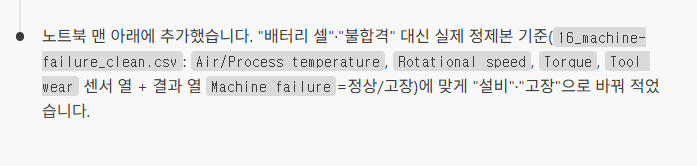

## 후보 비교 - 이 데이터로 풀 수 있는 문제 3개

| 후보 | 결과 열 | 누가 쓰나 | 무엇을 결정하나 | 언제 결정하나 |
|---|---|---|---|---|
| ① 고장 예측(실시간) | Machine failure | 설비 정비 담당자 | 이 설비를 정밀 점검(예방 정비)으로 보낼지 말지 | 센서 측정값(Air temperature, Process temperature, Rotational speed, Torque, Tool wear)이 표에 올라온 직후 |
| ② 고장 예측(작업 단위) | Machine failure | 생산 라인 관리자 | 이번 작업(교대·배치)에서 해당 설비를 계속 돌릴지, 가동을 멈추고 순서를 바꿀지 | 한 작업 구간의 센서 측정값이 다 쌓인 시점 |
| ③ 제품 등급 검증 | Type | 품질관리 담당자 | 센서로 측정된 성능이 신고된 등급(L/M/H)과 맞는지, 재분류가 필요한지 | 출하 전, 센서 측정값이 표에 올라온 직후 |

①·②는 같은 결과 열(Machine failure)이지만 "누가·언제"가 달라서 다른 문제다: ①은 설비 하나하나를 실시간으로 보는 것이고, ②는 작업 구간 단위로 묶어서 라인 운영을 결정하는 것

## Step 2. 쓰는 데이터

| 항목 | 내용 |
|---|---|
| 출처 | data/16_machine-failure.csv (정제 후 사용) |
| 규모 | 10000행 x 7열 |
| 입력으로 쓸 열 | 숫자로 된 측정 열 5개 (Air temperature [K], Process temperature [K], Rotational speed [rpm], Torque [Nm], Tool wear [min]) |
| 결과 열 (TARGET) | Machine failure |
| 결과 열의 값 | 정상 / 고장 |
| 기준선이 될 숫자 | 고장 339건 (3.4%) |

## Step 3. 한계

- `Type`(설비·제품 등급: L/M/H)이 표에 있지만, 정제본 입력에는 숫자 열 5개만 썼다. 등급별 차이는 아직 보지 않았다
- 이 데이터에는 시간·날짜를 나타내는 열이 아예 없어서, 계절이나 부품 교체 같은 긴 흐름이 담겨 있는지조차 확인할 수 없다
- 특정 측정값(예: `Torque [Nm]`, `Tool wear [min]`)이 높은 구간에서 고장이 많이 관찰되더라도, 그것이 원인이라고는 말할 수 없다

# 실습 17 - 모델링 계획표

## 모델링 계획

| # | 하는 일 | 내 경우엔 | 막힐 것 같나 |
|---|---|---|---|
| 1 | 파일 불러오기 | [results/16_machine-failure_clean.csv] | |
| 2 | 빈칸 채우기 | [입력 열 5개(Air temperature [K], Process temperature [K], Rotational speed [rpm], Torque [Nm], Tool wear [min])를 각 열의 중앙값으로] | |
| 3 | 결과 열을 숫자로 | [Machine failure가 "고장"이면 1, "정상"이면 0] | |
| 4 | 입력과 정답 나누기 | [입력은 위 숫자 열 5개, 정답은 Machine failure] | |
| 5 | 학습용·시험용 나누기 | [8대 2, 고장 비율(3.4%)을 stratify로 양쪽에 맞춤] | |
| 6 | 기준 모델 점수 재기 | [전부 "정상"(0)이라고만 답하는 모델] | |
| 7 | 모델 하나 학습시키기 | [표준화 후 로지스틱 회귀] | |
| 8 | 결과 읽기 | [기준 모델과 나란히, 정확도뿐 아니라 정밀도·재현율도 같이 봄] | |

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import precision_score, recall_score, confusion_matrix

# ① 정제본을 불러오고, 숫자 열만 입력으로 쓴다
df = pd.read_csv("results/16_machine-failure_clean.csv")
입력열 = ["Air temperature [K]", "Process temperature [K]", "Rotational speed [rpm]", "Torque [Nm]", "Tool wear [min]"]
X = df[입력열]

# ② 입력 열의 빈칸을 그 열의 중앙값으로 채운다
X = X.fillna(X.median())

# ③ 결과 열(Machine failure)이 "고장"이면 1, 아니면 0
y = (df["Machine failure"] == "고장").astype(int)

# ④ 학습용·시험용을 8대 2로 나눈다 - stratify로 1 비율을 양쪽에 맞춘다
학습입력, 시험입력, 학습정답, 시험정답 = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"학습용 {len(학습입력)}건 (고장 비율 {학습정답.mean()*100:.2f}%)")
print(f"시험용 {len(시험입력)}건 (고장 비율 {시험정답.mean()*100:.2f}%)")

# ⑤ 기준 모델 - 학습 없이 전부 0(정상)이라 답했을 때 정확도
기준정확도 = (시험정답 == 0).mean()
print(f"기준 모델 정확도: {기준정확도*100:.2f}%")

# ⑥ 표준화한 뒤 로지스틱 회귀 모델을 학습시킨다
모델 = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
모델.fit(학습입력, 학습정답)

# ⑦ 시험용으로 채점한다
예측 = 모델.predict(시험입력)
내정확도 = (예측 == 시험정답).mean()

지목건수 = (예측 == 1).sum()
그중진짜 = ((예측 == 1) & (시험정답 == 1)).sum()
실제건수 = (시험정답 == 1).sum()
정밀도 = precision_score(시험정답, 예측)
재현율 = recall_score(시험정답, 예측)

print(f"내 모델 정확도: {내정확도*100:.2f}%")
print(f"지목한 건수: {지목건수}건")
print(f"그중 진짜: {그중진짜}건")
print(f"시험용의 실제 건수: {실제건수}건")
print(f"정밀도: {정밀도:.3f}")
print(f"재현율: {재현율:.3f}")

# ⑧ 혼동행렬로 네 칸을 다 풀어서 본다
맞게넘김, 헛지목, 놓침, 제대로잡음 = confusion_matrix(시험정답, 예측).ravel()
print()
print(f"실제 0(정상) {맞게넘김 + 헛지목}건 중: 맞게 0이라 함 {맞게넘김}건 / 잘못 1이라 지목(헛지목) {헛지목}건")
print(f"실제 1(고장) {놓침 + 제대로잡음}건 중: 놓치고 0이라 함 {놓침}건 / 맞게 1이라 지목(제대로잡음) {제대로잡음}건")

학습용 8000건 (고장 비율 3.39%)
시험용 2000건 (고장 비율 3.40%)
기준 모델 정확도: 96.60%
내 모델 정확도: 96.85%
지목한 건수: 13건
그중 진짜: 9건
시험용의 실제 건수: 68건
정밀도: 0.692
재현율: 0.132

실제 0(정상) 1932건 중: 맞게 0이라 함 1928건 / 잘못 1이라 지목(헛지목) 4건
실제 1(고장) 68건 중: 놓치고 0이라 함 59건 / 맞게 1이라 지목(제대로잡음) 9건


## 도전 - 입력에서 빼야 할 열이 있나 (데이터 누수 점검)

| 종류 | 있나 | 열 이름 | 어떻게 할까 |
|---|---|---|---|
| 번호·순번 열 | 없음 | - | - |
| 판단 시점 이후에 찍히는 열 | 없음 | - | 판단 시점(자동 측정이 끝나고 값이 표에 올라온 직후)에 이미 다 찍혀 있는 센서 측정값만 정제본에 남아 있다 |
| 결과 열의 사본 | 없음 | - | - |

- 확인한 것 : 숫자 열 5개(Air temperature [K], Process temperature [K], Rotational speed [rpm], Torque [Nm], Tool wear [min])의 값 분포와 nunique를 확인해 순번이 아님을 확인했고, 결과 열(Machine failure, 고장=1)과의 상관계수도 실제로 재봤다 (Air temperature 0.083 / Process temperature 0.036 / Rotational speed -0.044 / Torque 0.191 / Tool wear 0.105 — 모두 0.2 미만)
- 결론 : 5개 열 모두 입력에 그대로 쓴다. 빼야 할 열이 없다

# 실습 18 - 모델링 v1

## 모델링 v1

### 문법 노트 - 코드에서 찾을 이름

| 이름 | 뜻 |
|---|---|
| features | 모델에 넣는 입력 열 목록 |
| label | 정답표 - 찾으려는 쪽이면 1, 아니면 0 |
| X / y | 입력 / 정답 |
| X_train, X_test | 학습용 입력 / 시험용 입력 |
| y_train, y_test | 학습용 정답 / 시험용 정답 |
| baseline | 기준 모델 - 학습 없이 전부 아니라고 답하는 것 |
| model | 학습시킨 모델 |
| y_pred | 모델이 내놓은 답 |
| precision / recall | 정밀도 / 재현율 |

### 내 갈래

- 갈래 : [A - 맞히기]
- 결과 열 : [result] / 관심 갈래 : [고장]
- 이 기준으로 정한 이유 : [현장에서 걸러내려는 게 고장 셀이라서]

In [3]:
import pandas as pd  # 표 다루는 도구

# ① 정제본 파일을 불러온다
df = pd.read_csv("results/16_machine-failure_clean.csv")  # 이미 정리된 설비 고장 데이터

# ② 숫자로 된 열만 입력으로 쓴다 - 결과 열(Machine failure)은 답이므로 뺀다
입력열 = ["Air temperature [K]", "Process temperature [K]", "Rotational speed [rpm]", "Torque [Nm]", "Tool wear [min]"]  # 입력으로 쓸 숫자 열 5개
X = df[입력열]  # 입력(조건 열)만 따로 뗀다

# ③ 입력 열의 빈칸을 그 열의 중앙값으로 채운다
X = X.fillna(X.median())  # 열마다 중앙값으로 빈칸을 메운다

# ④ 결과 열(Machine failure)이 "고장"이면 1, 아니면 0인 label 열을 만든다
y = (df["Machine failure"] == "고장").astype(int)  # 참이면 1, 거짓이면 0

print("입력 형태:", X.shape)  # (행 수, 열 수)
print(f"label 1(고장) 비율: {y.mean()*100:.2f}% ({y.sum()}건 / {len(y)}건)")  # 고장 비율 확인


입력 형태: (10000, 5)
label 1(고장) 비율: 3.39% (339건 / 10000건)


In [4]:
from sklearn.model_selection import train_test_split  # 학습용·시험용 나누는 도구

# ⑤ 학습용·시험용을 8대 2로 나눈다 - stratify로 1 비율을 양쪽에 맞춘다
학습입력, 시험입력, 학습정답, 시험정답 = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)  # 시험용은 이후 학습에 쓰지 않는다

print(f"학습용 {len(학습입력)}건 (1 비율 {학습정답.mean()*100:.2f}%)")  # 학습용 크기·비율
print(f"시험용 {len(시험입력)}건 (1 비율 {시험정답.mean()*100:.2f}%)")  # 시험용 크기·비율

# ⑥ 기준 모델 점수 - 학습 없이 전부 0(정상)이라 답했을 때 정확도
기준정확도 = (시험정답 == 0).mean()  # 실제 0인 비율이 곧 그 정확도
print(f"기준 모델 정확도: {기준정확도*100:.2f}%")


학습용 8000건 (1 비율 3.39%)
시험용 2000건 (1 비율 3.40%)
기준 모델 정확도: 96.60%


In [5]:
from sklearn.preprocessing import StandardScaler  # 값을 같은 자로 맞추는 도구
from sklearn.linear_model import LogisticRegression  # 분류 모델
from sklearn.pipeline import make_pipeline  # 표준화+모델을 한 번에 묶는 도구
from sklearn.metrics import precision_score, recall_score  # 정밀도·재현율 계산 도구

# ⑦ 표준화한 뒤 로지스틱 회귀 모델 하나를 학습시킨다
모델 = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))  # 표준화 + 로지스틱 회귀를 하나로 묶는다
모델.fit(학습입력, 학습정답)  # 학습용으로만 배운다

# ⑧ 시험용으로 채점한다 - 시험용은 학습에 쓰지 않는다
예측 = 모델.predict(시험입력)  # 시험용 입력만 넣어서 예측
내정확도 = (예측 == 시험정답).mean()  # 맞힌 비율

지목건수 = (예측 == 1).sum()  # 모델이 1이라고 지목한 건수
그중진짜 = ((예측 == 1) & (시험정답 == 1)).sum()  # 지목한 것 중 실제로도 1인 것
실제건수 = (시험정답 == 1).sum()  # 시험용에서 실제로 1인 건수
정밀도 = precision_score(시험정답, 예측)  # 지목한 것 중 맞은 비율
재현율 = recall_score(시험정답, 예측)  # 실제 1 중 잡아낸 비율

# 요청한 일곱 줄을 그대로 출력
print(f"기준 모델 정확도: {기준정확도*100:.2f}%")
print(f"내 모델 정확도: {내정확도*100:.2f}%")
print(f"지목한 건수: {지목건수}건")
print(f"그중 진짜: {그중진짜}건")
print(f"시험용의 실제 건수: {실제건수}건")
print(f"정밀도: {정밀도:.3f}")
print(f"재현율: {재현율:.3f}")


기준 모델 정확도: 96.60%
내 모델 정확도: 96.85%
지목한 건수: 13건
그중 진짜: 9건
시험용의 실제 건수: 68건
정밀도: 0.692
재현율: 0.132


In [6]:
# 앞 모델(모델)은 그대로 둔다 - class_weight="balanced"만 추가한 새 모델을 새 이름으로 만든다
모델_가중치 = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, class_weight="balanced"))
모델_가중치.fit(학습입력, 학습정답)  # 학습용으로만 배운다

# 시험용으로 채점한다 - 시험용은 학습에 쓰지 않는다
예측_가중치 = 모델_가중치.predict(시험입력)

지목건수_가중치 = (예측_가중치 == 1).sum()  # 가중치 모델이 1이라고 지목한 건수
그중진짜_가중치 = ((예측_가중치 == 1) & (시험정답 == 1)).sum()  # 지목한 것 중 실제로도 1인 것
재현율_가중치 = recall_score(시험정답, 예측_가중치)  # 실제 1 중 잡아낸 비율

# 두 모델의 지목 건수 / 그중 진짜 / 재현율을 나란히 출력
print(f"기본 모델   - 지목 건수: {지목건수}건 / 그중 진짜: {그중진짜}건 / 재현율: {재현율:.3f}")
print(f"가중치 모델 - 지목 건수: {지목건수_가중치}건 / 그중 진짜: {그중진짜_가중치}건 / 재현율: {재현율_가중치:.3f}")


기본 모델   - 지목 건수: 13건 / 그중 진짜: 9건 / 재현율: 0.132
가중치 모델 - 지목 건수: 404건 / 그중 진짜: 57건 / 재현율: 0.838


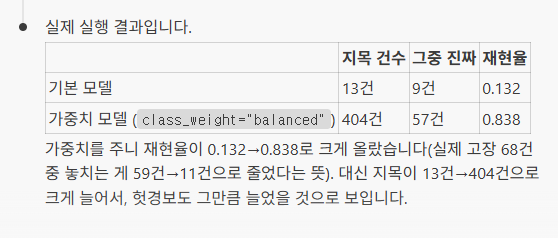

### 도전 - 하이퍼파라미터를 바꿔본 결과

| | 지목 | 그중 진짜 | 재현율 |
|---|---|---|---|
| 손 안 댐 | [13] | [9] | [0.132] |
| 바꾼 뒤 | [404] | [57] | [0.838] |

- 알게 된 것 : [놓친 것은 줄었지만 헛걸음이 13건에서 404건으로 늘었다. 어느 쪽이 나은지는 재검사 한 건에 드는 비용을 알아야 정해진다]

# 실습 19 - 결과 한 장

## v1 결과

| | 정확도 | 지목 | 그중 진짜 | 재현율 |
|---|---|---|---|---|
| 기준 모델 (전부 정상) | [96.60%] | [0건] | [0건] | [0.000] |
| 내 모델 v1 | [96.85%] | [13건] | [9건] | [0.132] |

- 시험용에 실제로 있던 고장 : [68건]
- 한 줄 요약 : [정확도는 기준보다 0.25%p 올랐고 지목한 13건 중 9건이 실제 고장이었다. 다만 실제 68건 중 59건은 못 잡았다]

### 다음에 할 일

1. [드문 쪽을 무겁게 세는 설정으로 지목 건수를 늘려보기]
2. [지목을 늘렸을 때 헛걸음이 얼마나 느는지 같이 재기]
3. [재검사 한 건에 드는 비용을 알아보고, 어느 쪽이 나은지 정하기]

## 쉽게 다시 쓴 버전 - v1 결과 (숫자는 그대로)

### v1 결과 (쉬운 말 버전)

| | 정확도(맞힌 비율) | 지목 | 그중 진짜 | 재현율(실제 있는 대상 중 잡아낸 비율) |
|---|---|---|---|---|
| 기준 모델(아무것도 배우지 않고 한 가지로만 답하는 비교용 모델) — 전부 정상 | 96.60% | 0건 | 0건 | 0.000 |
| 내 모델 v1 | 96.85% | 13건 | 9건 | 0.132 |

- 시험용에 실제로 있던 고장 : 68건
- 한 줄 요약 : 정확도(맞힌 비율)는 기준보다 0.25%p(퍼센트 두 값을 그대로 뺀 차이) 올랐고, 지목한 13건 중 9건이 실제 고장이었다. 다만 실제 68건 중 59건은 놓쳤다(재현율 = 실제 있는 대상 중 잡아낸 비율 = 0.132)

---
- 원인이라고 단정한 문장 확인 : "v1 결과" 칸 안에서는 "~때문에", "~가 원인이다"처럼 단정하는 문장을 찾지 못해서, 이 부분은 고칠 게 없었다
- 참고 : "카드에 옮겨 적을 것" 칸은 이 노트북에 아직 없어서(project_v1에만 있음), 지어내지 않고 v1 결과 칸만 고쳤다

- 오늘 정한 문제 : [셀 검사 측정값으로 정밀 재검사 대상을 먼저 고르는 것]
- 쓴 데이터 : [셀 검사 기록10000행 x 7열 / 고장 339건 3.4%]
- 오늘 나온 숫자 : [기준 96.60% / v1 96.85% / 지목 13건 중 진짜 9건 / 재현율 0.132]
- 다음에 손댈 자리 : [지목 건수를 늘리는 설정]

### 도전 - 그래서 무엇을 하자는 것인가

- 모델이 고장 가능성이 높다고 지목한 설비는, 라인을 세우기 전에 정밀 점검(예방 정비)으로 먼저 돌리자는 것. 지금 v1로는 실제 고장 68건 중 9건만 걸러지므로, 이 상태로 현장에 걸기에는 이르다